In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df =pd.read_csv("Mobiles Dataset (2025).csv",encoding="cp1252")


### Data Understanding

In [ ]:
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Name               930 non-null    object
 1   Model Name                 930 non-null    object
 2   Mobile Weight              930 non-null    object
 3   RAM                        930 non-null    object
 4   Front Camera               930 non-null    object
 5   Back Camera                930 non-null    object
 6   Processor                  930 non-null    object
 7   Battery Capacity           930 non-null    object
 8   Screen Size                930 non-null    object
 9   Launched Price (Pakistan)  930 non-null    object
 10  Launched Price (India)     930 non-null    object
 11  Launched Price (China)     930 non-null    object
 12  Launched Price (USA)       930 non-null    object
 13  Launched Price (Dubai)     930 non-null    object
 14  Launched Y

In [ ]:
df.shape

(930, 15)

In [ ]:
df.describe()

,Launched Year
count,930.000000
mean,2022.193548
std,1.862080
min,2014.000000
25%,2021.000000
50%,2023.000000
75%,2024.000000
max,2025.000000


In [ ]:
df.columns

Index(['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera',
       'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size',
       'Launched Price (Pakistan)', 'Launched Price (India)',
       'Launched Price (China)', 'Launched Price (USA)',
       'Launched Price (Dubai)', 'Launched Year'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Company Name,0
Model Name,0
Mobile Weight,0
RAM,0
Front Camera,0
Back Camera,0
Processor,0
Battery Capacity,0
Screen Size,0
Launched Price (Pakistan),0


In [ ]:
df.nunique()

,0
Company Name,19
Model Name,908
Mobile Weight,148
RAM,11
Front Camera,29
Back Camera,91
Processor,217
Battery Capacity,147
Screen Size,97
Launched Price (Pakistan),157


In [ ]:
df["Company Name"]

,Company Name
0,Apple
1,Apple
2,Apple
3,Apple
4,Apple
...,...
925,Poco
926,Poco
927,Samsung
928,Samsung


In [ ]:
# duplicate rows count

df.duplicated().sum()

np.int64(15)

## DATA CLEANING

In [ ]:
df.shape

(930, 15)

In [ ]:
# Drop exact duplicate rows
df = df.drop_duplicates()

In [ ]:
df.shape

(915, 15)

In [ ]:
import pandas as pd
import re
#  we are performing data cleaning to remove any symbols from our data
# Reload a fresh copy to ensure clean state
df = pd.read_csv("Mobiles Dataset (2025).csv", encoding="cp1252").drop_duplicates()

def clean_column(value):
    if pd.isna(value):
        return value
    # Remove everything except digits and decimal point
    cleaned = re.sub(r'[^0-9.]', '', str(value))
    return cleaned if cleaned != '' else None

# Columns to clean
columns_to_clean = [
    'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera',
    'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)',
    'Launched Price (India)', 'Launched Price (China)',
    'Launched Price (USA)', 'Launched Price (Dubai)'
]

for col in columns_to_clean:
    df[col] = df[col].apply(clean_column)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data cleaning complete. Verifying 'Launched Price (India)' values:")
print(df[['Model Name', 'Launched Price (India)']].head())
print(f"\nMissing values in India Price: {df['Launched Price (India)'].isna().sum()}")

Data cleaning complete. Verifying 'Launched Price (India)' values:
             Model Name  Launched Price (India)
0       iPhone 16 128GB                   79999
1       iPhone 16 256GB                   84999
2       iPhone 16 512GB                   89999
3  iPhone 16 Plus 128GB                   89999
4  iPhone 16 Plus 256GB                   94999

Missing values in India Price: 0


In [ ]:
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,224999.0,79999,5799,799.0,2799,2024
1,Apple,iPhone 16 256GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,234999.0,84999,6099,849.0,2999,2024
2,Apple,iPhone 16 512GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,244999.0,89999,6499,899.0,3199,2024
3,Apple,iPhone 16 Plus 128GB,203.0,6.0,12.0,48.0,A17 Bionic,4200,6.7,249999.0,89999,6199,899.0,3199,2024
4,Apple,iPhone 16 Plus 256GB,203.0,6.0,12.0,48.0,A17 Bionic,4200,6.7,259999.0,94999,6499,949.0,3399,2024


In [ ]:
df

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,224999.0,79999,5799,799.0,2799,2024
1,Apple,iPhone 16 256GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,234999.0,84999,6099,849.0,2999,2024
2,Apple,iPhone 16 512GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,244999.0,89999,6499,899.0,3199,2024
3,Apple,iPhone 16 Plus 128GB,203.0,6.0,12.0,48.0,A17 Bionic,4200,6.7,249999.0,89999,6199,899.0,3199,2024
4,Apple,iPhone 16 Plus 256GB,203.0,6.0,12.0,48.0,A17 Bionic,4200,6.7,259999.0,94999,6499,949.0,3399,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000,12.1,66220.0,23999,2099,280.0,1029,2024
926,Poco,Pad 5G 256GB,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000,12.1,71220.0,25999,2299,300.0,1099,2024
927,Samsung,Galaxy Z Fold6 256GB,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400,7.6,604999.0,164999,13999,1899.0,7199,2024
928,Samsung,Galaxy Z Fold6 512GB,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400,7.6,544999.0,176999,15999,1719.0,7699,2024


In [ ]:
print('Missing values after cleaning numeric columns:')
print(df.isnull().sum())

Missing values after cleaning numeric columns:
Company Name                 0
Model Name                   0
Mobile Weight                0
RAM                          0
Front Camera                 0
Back Camera                  0
Processor                    0
Battery Capacity             0
Screen Size                  4
Launched Price (Pakistan)    1
Launched Price (India)       0
Launched Price (China)       0
Launched Price (USA)         0
Launched Price (Dubai)       0
Launched Year                0
dtype: int64


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Company Name,0
Model Name,0
Mobile Weight,0
RAM,0
Front Camera,0
Back Camera,0
Processor,0
Battery Capacity,0
Screen Size,0
Launched Price (Pakistan),0


In [ ]:
df.dtypes

,0
Company Name,object
Model Name,object
Mobile Weight,float64
RAM,float64
Front Camera,float64
Back Camera,float64
Processor,object
Battery Capacity,int64
Screen Size,float64
Launched Price (Pakistan),float64


In [ ]:
# Based on the data types, the following columns are 'object' type and will likely require encoding: 'Company Name', 'Model Name', and 'Processor'.

## EDA/VISUALIZATION

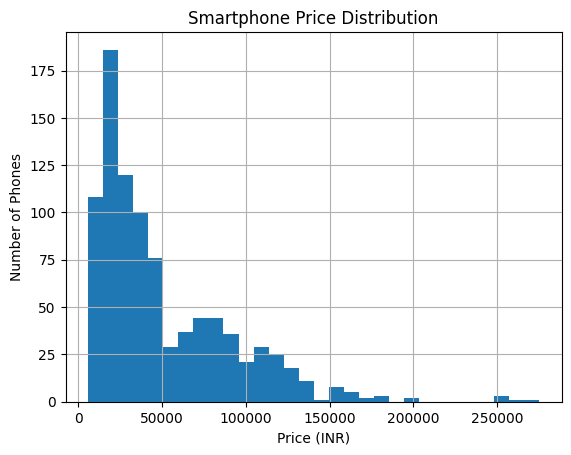

In [ ]:
# price distribution
target="Launched Price (India)"
df[target].hist(bins=30)

plt.xlabel("Price (INR)")
plt.ylabel("Number of Phones")
plt.title("Smartphone Price Distribution")
plt.show()

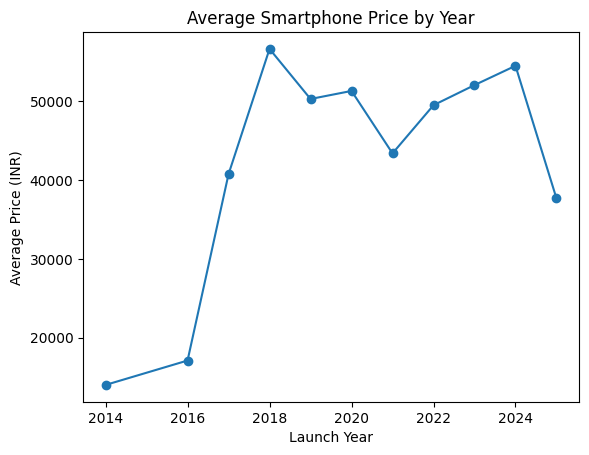

In [ ]:
# select the rows for which the price is greater than 1 lakh
# df[df[target]>100000]
# df.isnull().sum()

# average price by the year
year_price = df.groupby("Launched Year")[target].mean()

year_price.plot(marker="o")

plt.xlabel("Launch Year")
plt.ylabel("Average Price (INR)")
plt.title("Average Smartphone Price by Year")
plt.show()


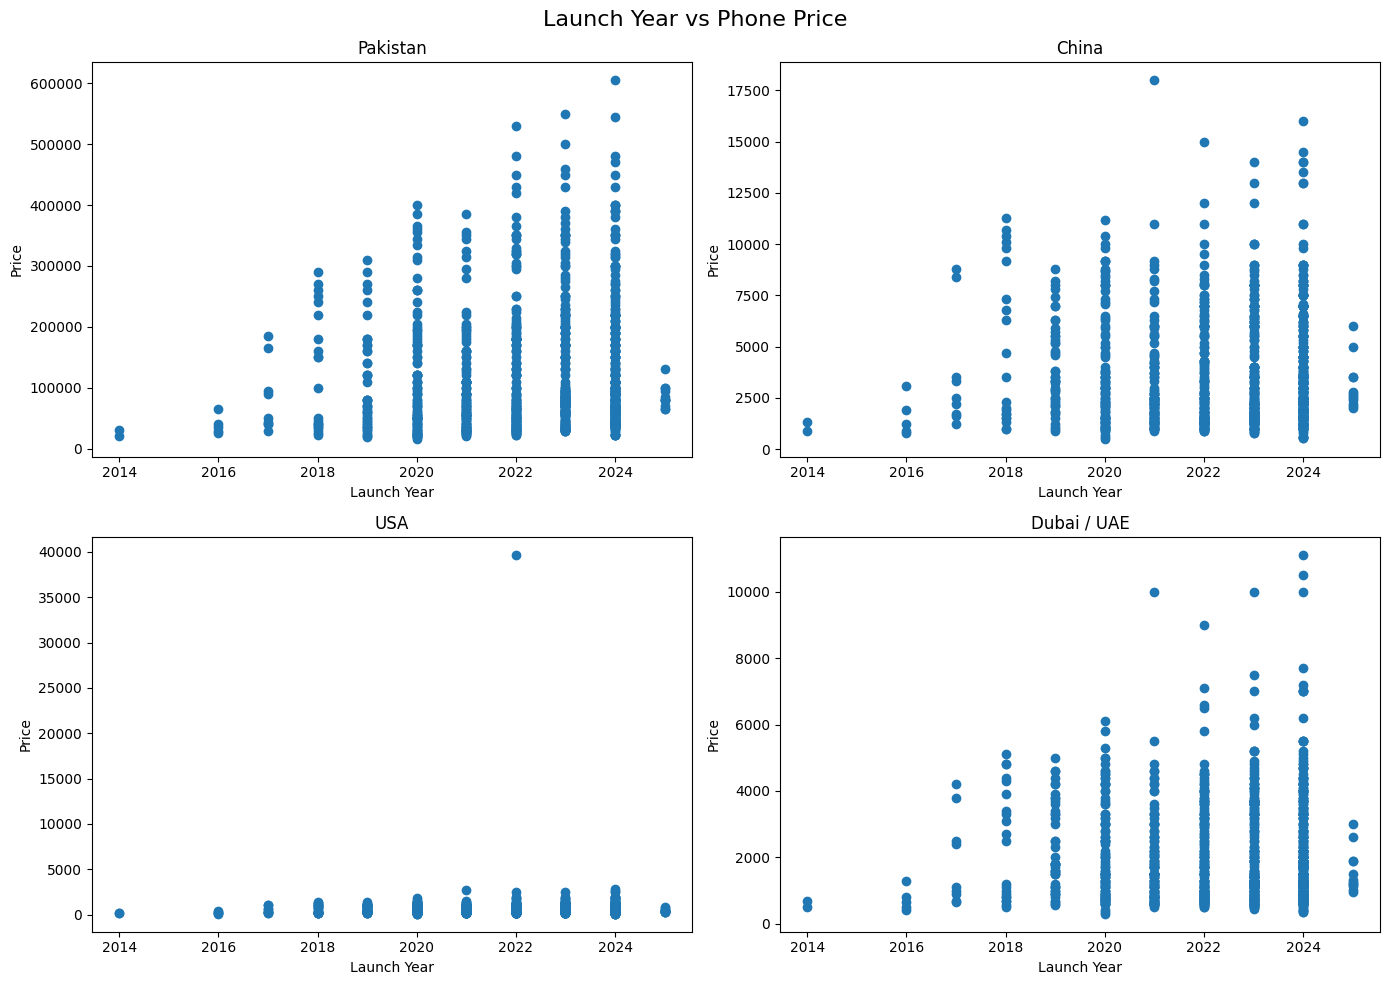

In [ ]:
# comparing avg price for all the countries
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pakistan
axes[0, 0].scatter(df["Launched Year"], df["Launched Price (Pakistan)"])
axes[0, 0].set_title("Pakistan")
axes[0, 0].set_xlabel("Launch Year")
axes[0, 0].set_ylabel("Price")

# China
axes[0, 1].scatter(df["Launched Year"], df["Launched Price (China)"])
axes[0, 1].set_title("China")
axes[0, 1].set_xlabel("Launch Year")
axes[0, 1].set_ylabel("Price")

# USA
axes[1, 0].scatter(df["Launched Year"], df["Launched Price (USA)"])
axes[1, 0].set_title("USA")
axes[1, 0].set_xlabel("Launch Year")
axes[1, 0].set_ylabel("Price")

# Dubai / UAE
axes[1, 1].scatter(df["Launched Year"], df["Launched Price (Dubai)"])
axes[1, 1].set_title("Dubai / UAE")
axes[1, 1].set_xlabel("Launch Year")
axes[1, 1].set_ylabel("Price")

plt.suptitle("Launch Year vs Phone Price", fontsize=16)
plt.tight_layout()
plt.show()

Company Name
Apple       102998.597938
Huawei      102798.571429
Sony         91665.666667
Google       70332.333333
Samsung      62026.264368
Xiaomi       57258.259259
Honor        48850.648352
Oppo         46485.826087
OnePlus      45734.849057
iQOO         43999.000000
Tecno        36806.692308
Vivo         35770.267442
Motorola     30757.620690
Realme       26147.652174
Lenovo       25392.400000
Poco         24999.000000
POCO         22649.000000
Infinix      17489.909091
Nokia        13771.727273
Name: Launched Price (India), dtype: float64


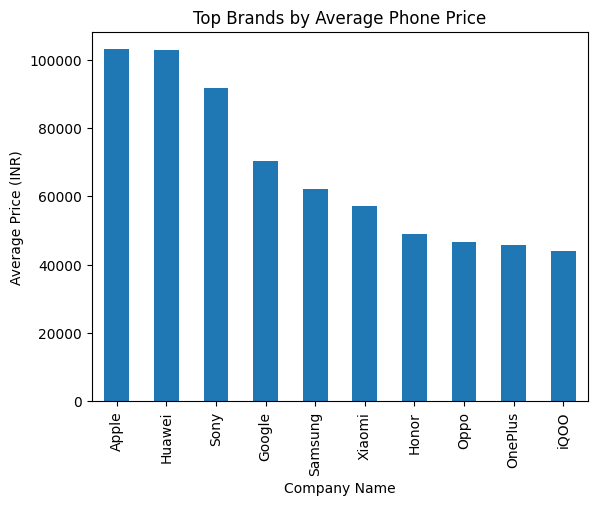

In [ ]:
# Brand-wise average price
brand_price = (
    df.groupby("Company Name")[target]
      .mean()
      .sort_values(ascending=False)
)
print(brand_price)
brand_price.head(10).plot(kind="bar")

plt.ylabel("Average Price (INR)")
plt.title("Top Brands by Average Phone Price")
plt.show()

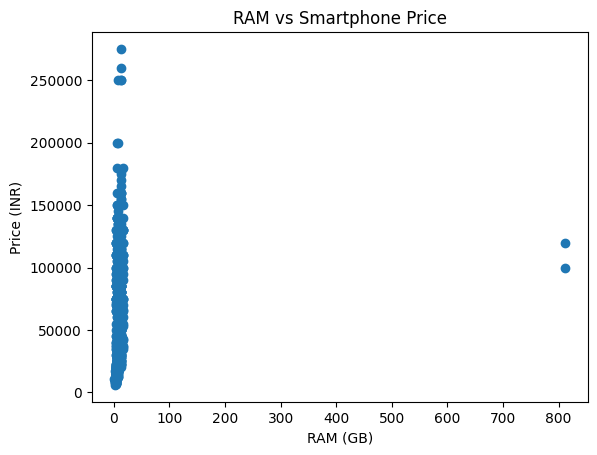

In [ ]:
# RAM vs Price
plt.scatter(df["RAM"], df[target])

plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")
plt.title("RAM vs Smartphone Price")
plt.show()

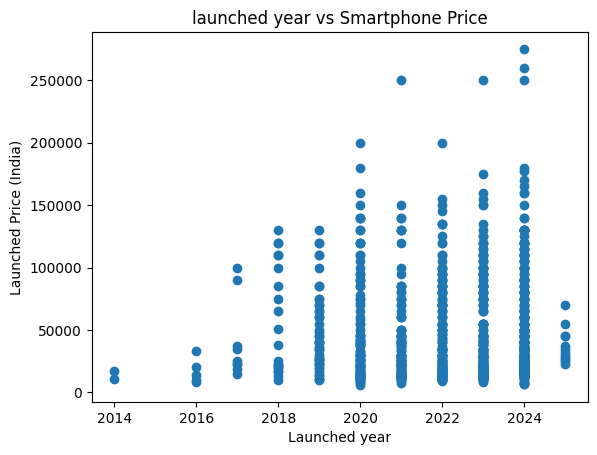

In [ ]:
# Launch Year vs Price
plt.scatter(df["Launched Year"], df[target])

plt.xlabel("Launched year")
plt.ylabel(target)
plt.title("launched year vs Smartphone Price")
plt.show()


In [ ]:
numeric_cols = [
    "RAM",
    # "Storage",
    "Battery Capacity",
    # "Camera",
    "Launched Year",
    target
]

print(df[numeric_cols].corr()[target].sort_values(ascending=False))

Launched Price (India)    1.000000
RAM                       0.103352
Launched Year             0.060136
Battery Capacity         -0.005743
Name: Launched Price (India), dtype: float64


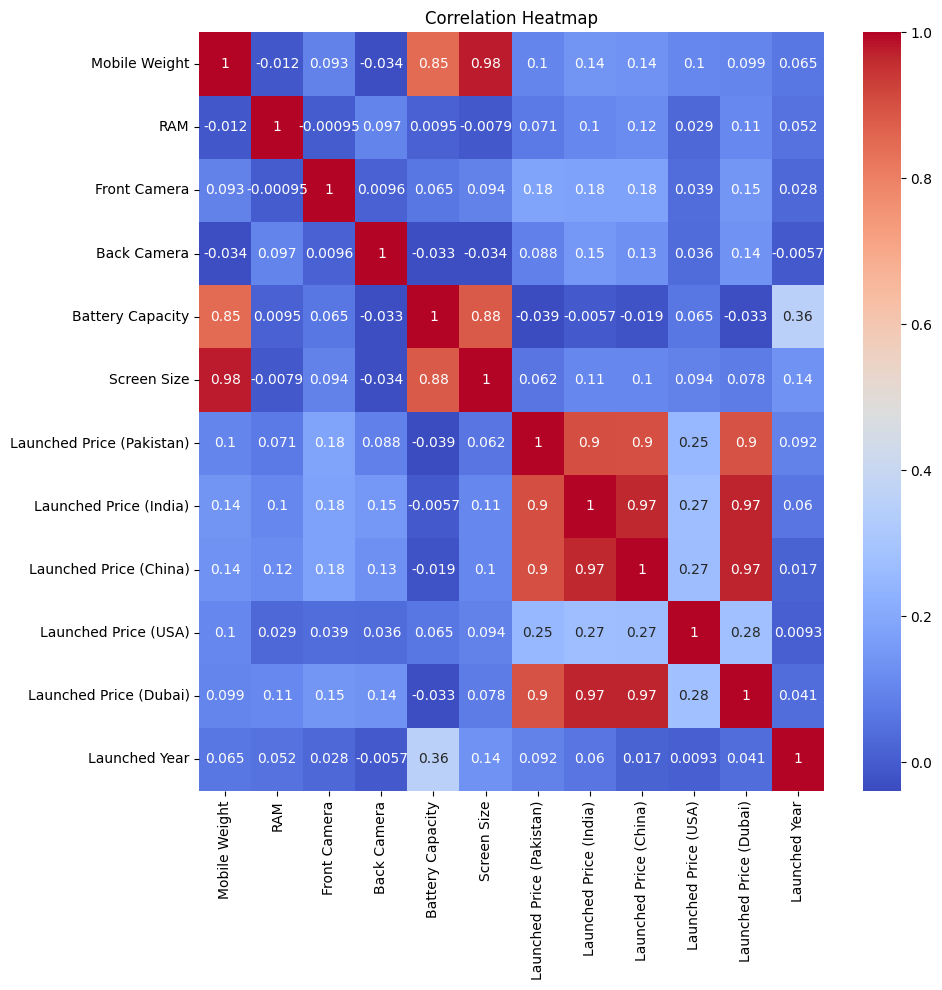

In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## FEATURE ENGINEERING AND PREPROCESSING
*extracting the most important features, encoding the data etc.*|

Feature engineering involves creating new features or transforming existing ones to improve the performance of machine learning models.

In [ ]:
# print("### Feature Engineering & Categorical Encoding ###")

# # -----------------------------------------
# # 1. Create new useful features
# # -----------------------------------------

# # Total camera megapixels
# df["Total Camera MP"] = (
#     df["Front Camera"] + df["Back Camera"]
# )

# # Battery efficiency relative to screen size
# df["Battery per Screen"] = (
#     df["Battery Capacity"] / df["Screen Size"]
# )

# # Weight relative to screen size
# df["Weight per Screen"] = (
#     df["Mobile Weight"] / df["Screen Size"]
# )

# # Phone age
# df["Phone Age"] = (
#     2026 - df["Launched Year"]
# )


# # -----------------------------------------
# # 2. Remove unwanted / leakage columns
# # -----------------------------------------

# # Indian price is our TARGET, so don't include it in X
# target = "Launched Price (India)"

# # Other country prices should NOT be used as features
# # because they would cause price leakage.
# price_columns = [
#     "Launched Price (Pakistan)",
#     "Launched Price (China)",
#     "Launched Price (USA)",
#     "Launched Price (Dubai)"
# ]

# df = df.drop(
#     columns=price_columns,
#     errors="ignore"
# )


# # -----------------------------------------
# # 3. Remove Model Name
# # -----------------------------------------

# # Model Name has potentially hundreds/thousands
# # of unique values, so don't one-hot encode it
# # for the first version of the model.

# df = df.drop(
#     columns=["Model Name"],
#     errors="ignore"
# )


# # -----------------------------------------
# # 4. Encode categorical variables
# # -----------------------------------------

# categorical_cols = [
#     "Company Name",
#     "Processor"
# ]

# df_encoded = pd.get_dummies(
#     df,
#     columns=categorical_cols,
#     drop_first=True
# )


# # -----------------------------------------
# # 5. Display results
# # -----------------------------------------

# print("Original number of columns:", df.shape[1])
# print("Number of columns after encoding:", df_encoded.shape[1])

# print("\nColumns after feature engineering:")
# print(df_encoded.columns.tolist())

# print("\nFirst 5 rows:")
# print(df_encoded.head())

## Note ~
i dropped the previous code because it was increasing the number of columns due to one hot encoding of processor model name and company name which would have led to curse of dimensioanlity or sparsity and ml models like linear regression and logistic regression fails to work on datas that have high sparsity

In [ ]:
# df_encoded.shape

In [ ]:
# df.shape

In [ ]:
print("Company:", df["Company Name"].nunique())
print("Processor:", df["Processor"].nunique())

Company: 19
Processor: 217


In [ ]:
categorical_cols = [
    "Company Name",
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.shape)

(910, 32)


In [ ]:
# df["Processor"].value_counts()

In [ ]:
# Numerical
# ├── Mobile Weight
# ├── RAM
# ├── Front Camera
# ├── Back Camera
# ├── Battery Capacity
# ├── Screen Size
# ├── Launch Year
# ├── Total Camera MP
# ├── Battery per Screen
# ├── Weight per Screen
# └── Phone Age

# Categorical
# ├── Company Name → One-Hot
# └── Processor Brand → One-Hot

# Target
# └── Launched Price (India)

In [ ]:
X = df.drop(columns=[
    "Launched Price (India)",
    "Launched Price (Pakistan)",
    "Launched Price (China)",
    "Launched Price (USA)",
    "Launched Price (Dubai)",
    "Model Name" # Drop Model Name due to high cardinality
])

y = df["Launched Price (India)"]

In [ ]:
X

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Year
0,Apple,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.10,2024
1,Apple,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.10,2024
2,Apple,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.10,2024
3,Apple,203.0,6.0,12.0,48.0,A17 Bionic,4200,6.70,2024
4,Apple,203.0,6.0,12.0,48.0,A17 Bionic,4200,6.70,2024
...,...,...,...,...,...,...,...,...,...
924,POCO,198.0,6.0,8.0,50.0,MediaTek Dimensity 7025,5110,6.67,2024
925,Poco,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000,12.10,2024
926,Poco,571.0,8.0,8.0,8.0,Snapdragon 7s Gen 2,10000,12.10,2024
927,Samsung,239.0,12.0,104.0,50.0,Snapdragon 8 Gen 3,4400,7.60,2024


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.head())

X shape: (910, 9)
y shape: (910,)

Features:
['Company Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Launched Year']

Target:
0    79999
1    84999
2    89999
3    89999
4    94999
Name: Launched Price (India), dtype: int64


In [ ]:
print(X.isnull().sum().sum())
print(y.isnull().sum())

0
0


## Train/ test / split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (728, 9)
Testing data: (182, 9)


### standard scaling the values for linear regression model

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns that are not transformed
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
print('Shape of processed X_train:', X_train_processed.shape)
print('Shape of processed X_test:', X_test_processed.shape)

Shape of processed X_train: (728, 231)
Shape of processed X_test: (182, 231)


Now that the features are scaled and encoded, we can proceed with training the linear regression model.

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_processed, y_train)


LinearRegression()

## linear regression with pipeline

In [ ]:
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LinearRegression

# lr_pipeline = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", LinearRegression())
# ])
# lr_pipeline.fit(X_train, y_train)
# y_pred_lr = lr_pipeline.predict(X_test)
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# mae_lr = mean_absolute_error(y_test, y_pred_lr)

# rmse_lr = np.sqrt(
#     mean_squared_error(y_test, y_pred_lr)
# )

# r2_lr = r2_score(y_test, y_pred_lr)

# print("Linear Regression")
# print("------------------")
# print("MAE :", mae_lr)
# print("RMSE:", rmse_lr)
# print("R²  :", r2_lr)

The Linear Regression model has been trained. Next, we can evaluate its performance on the test set.

In [ ]:
print('Linear Regression model trained successfully.')

Linear Regression model trained successfully.


In [ ]:
y_pred_lr  = linear_reg_model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score
# import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
# print("------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 14466.20723792314
RMSE: 20890.373542785295
R²  : 0.7158249499432761


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

#### evaluate

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest")
print("------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)


Random Forest
------------------
MAE : 8433.140491041313
RMSE: 12907.28630754209
R²  : 0.8915165667939662


## XGBOOST

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)

In [ ]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost")
print("------------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)


XGBoost
------------------
MAE : 7617.2529296875
RMSE: 12025.538158435987
R²  : 0.9058321714401245


#### Comparing all the 3 models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

print(results)

               Model           MAE          RMSE        R2
0  Linear Regression  14466.207238  20890.373543  0.715825
1      Random Forest   8433.140491  12907.286308  0.891517
2            XGBoost   7617.252930  12025.538158  0.905832


In [ ]:
results.sort_values("MAE")
# MAE  → lower is better
# RMSE → lower is better
# R²   → higher is better

,Model,MAE,RMSE,R2
2,XGBoost,7617.252930,12025.538158,0.905832
1,Random Forest,8433.140491,12907.286308,0.891517
0,Linear Regression,14466.207238,20890.373543,0.715825


In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_xgb
})

print(comparison.head(10))

   Actual Price  Predicted Price
0         12999     18109.707031
1         59999     69434.742188
2         36999     34588.281250
3         17999     17349.542969
4         29999     30254.791016
5        159999    155371.421875
6         32999     39908.191406
7         10999     10391.596680
8         15999     22374.857422
9         18999     22232.980469


### Visualization ~ Actual Vs predicted price

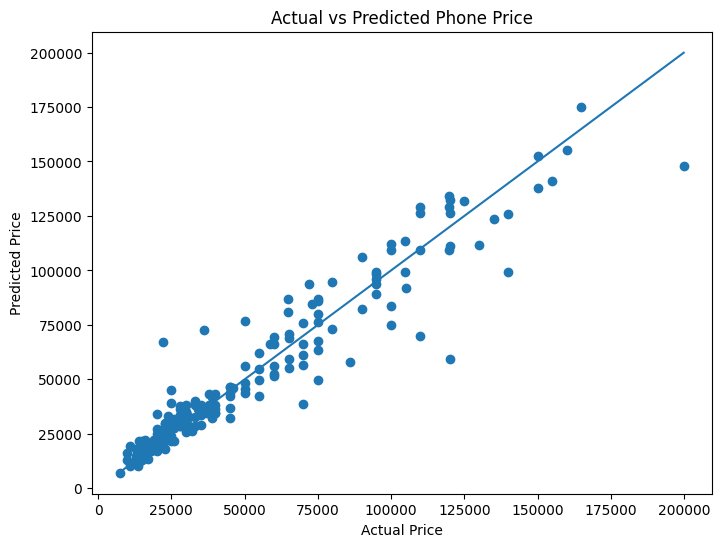

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_xgb
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Phone Price")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

#### checking XGBOOST's feature importance

In [ ]:
# importance = pd.Series(
#     xgb_model.feature_importances_,
#     index=X_train_processed.columns
# )

# importance = importance.sort_values(
#     ascending=False
# )

# print(importance.head(15))

In [ ]:
# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create a pandas Series for feature importances with correct names
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
)

importance = importance.sort_values(
    ascending=False
)

print("Top 15 XGBoost Feature Importances:")
print(importance.head(15))

Top 15 XGBoost Feature Importances:
num__Back Camera                     0.167019
cat__Company Name_Huawei             0.122936
cat__Company Name_Oppo               0.050068
cat__Company Name_Sony               0.046606
cat__Processor_A12 Bionic            0.045469
num__Front Camera                    0.039354
num__Mobile Weight                   0.038680
num__RAM                             0.037566
num__Screen Size                     0.036196
num__Battery Capacity                0.026280
cat__Company Name_OnePlus            0.025319
cat__Processor_Snapdragon 8 Gen 3    0.023969
cat__Processor_A17 Bionic            0.021461
cat__Company Name_POCO               0.020928
cat__Company Name_Infinix            0.020818
dtype: float32


/tmp/ipykernel_652/47827061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.head(15).values, y=importance.head(15).index, palette='viridis')


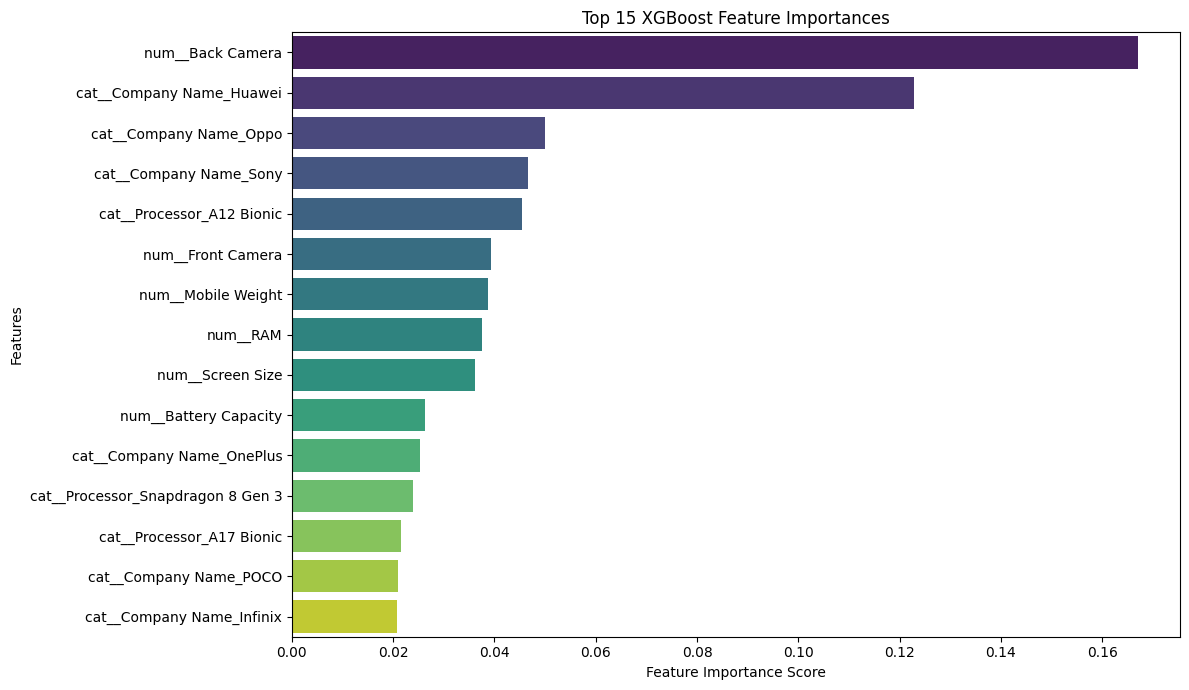

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=importance.head(15).values, y=importance.head(15).index, palette='viridis')
plt.title('Top 15 XGBoost Feature Importances')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## CROSS VALIDATION

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Create a pipeline that includes preprocessing and the XGBoost model
full_pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

scores = cross_val_score(
    full_pipeline_xgb, # Use the pipeline instead of just the model
    X, # Pass the original X, the pipeline will handle preprocessing
    y,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1 # Use all available cores for faster computation
)

mae_scores = -scores

print("MAE for each fold:", mae_scores)
print("Average MAE:", mae_scores.mean())
print("Std:", mae_scores.std())

MAE for each fold: [47224.609375   13253.91210938 21467.79882812 18512.671875
 16326.22265625]
Average MAE: 23357.04296875
Std: 12232.772280247173


## Hyperparameter Tuning with RandomizedSearchCV

To further optimize the XGBoost model, we can perform hyperparameter tuning. Instead of manually trying different combinations, we'll use `RandomizedSearchCV` to efficiently search through a defined range of hyperparameter values. This helps us find the best configuration that maximizes (or minimizes, in the case of error metrics) the model's performance on unseen data.

We will define a parameter distribution for some key hyperparameters of `XGBRegressor` and let `RandomizedSearchCV` explore different combinations.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
param_distributions = {
    'regressor__n_estimators': randint(100, 1000),  # Number of boosting rounds
    'regressor__learning_rate': uniform(loc=0.01, scale=0.2), # Step size shrinkage to prevent overfitting
    'regressor__max_depth': randint(3, 10),      # Maximum depth of a tree
    'regressor__subsample': uniform(loc=0.6, scale=0.4),    # Subsample ratio of the training instance
    'regressor__colsample_bytree': uniform(loc=0.6, scale=0.4), # Subsample ratio of columns when constructing each tree
    'regressor__gamma': uniform(loc=0, scale=0.5), # Minimum loss reduction required to make a further partition
    'regressor__reg_alpha': uniform(loc=0, scale=0.5) # L1 regularization term on weights
}

# Initialize RandomizedSearchCV
# We use the full_pipeline_xgb created earlier that includes the preprocessor and XGBoost regressor
random_search = RandomizedSearchCV(
    full_pipeline_xgb,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings that are sampled (adjust for computational budget)
    scoring='neg_mean_absolute_error', # Optimize for MAE
    cv=3,       # Number of folds for cross-validation
    verbose=1,  # Output progress
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

# Perform the random search
print("Starting RandomizedSearchCV...")
random_search.fit(X_train, y_train)
print("RandomizedSearchCV completed.")

Starting RandomizedSearchCV...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
RandomizedSearchCV completed.


In [ ]:
# Print the best parameters and best score found
print("Best parameters found:")
print(random_search.best_params_)
print("\nBest MAE (negative, so smaller absolute value is better):", -random_search.best_score_)

Best parameters found:
{'regressor__colsample_bytree': np.float64(0.6092249700165663), 'regressor__gamma': np.float64(0.2623873301291946), 'regressor__learning_rate': np.float64(0.08997219434305109), 'regressor__max_depth': 6, 'regressor__n_estimators': 799, 'regressor__reg_alpha': np.float64(0.18318092164684585), 'regressor__subsample': np.float64(0.7824279936868144)}

Best MAE (negative, so smaller absolute value is better): 8165.424641927083


After finding the best hyperparameters, we can retrieve the best model and evaluate it on the test set.

In [ ]:
# Get the best model from the random search
best_xgb_model_tuned = random_search.best_estimator_

# Make predictions on the test set using the tuned model
y_pred_xgb_tuned = best_xgb_model_tuned.predict(X_test)

# Evaluate the tuned model
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("\nTuned XGBoost Model Performance on Test Set")
print("------------------------------------------")
print("MAE :", mae_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("R²  :", r2_xgb_tuned)


Tuned XGBoost Model Performance on Test Set
------------------------------------------
MAE : 6852.59619140625
RMSE: 11031.630160588235
R²  : 0.9207547903060913


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


:Comparing these metrics with the previously obtained metrics for the untuned XGBoost model (`mae_xgb`, `rmse_xgb`, `r2_xgb`) to see the impact of hyperparameter tuning.

In [ ]:
# best set of parameters are:
# 'regressor__colsample_bytree': 0.609,
# 'regressor__gamma': 0.262,
# 'regressor__learning_rate': 0.089,
# 'regressor__max_depth': 6,
# 'regressor__n_estimators': 799,
# 'regressor__reg_alpha': 0.183,
# 'regressor__subsample': 0.782

#**Final visualization of xgb tuned model**

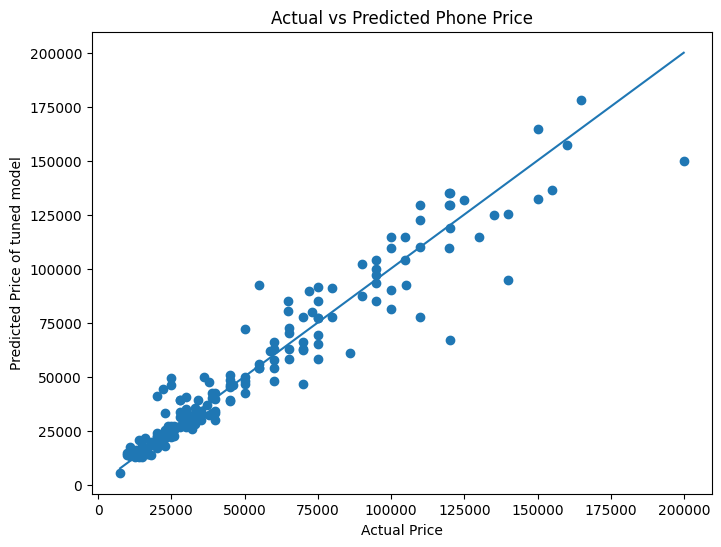

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_xgb_tuned
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price of tuned model")
plt.title("Actual vs Predicted Phone Price")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

## SHAP Explainability

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations by using Shapley values from cooperative game theory. This helps us understand how much each feature contributes to the prediction of a model.

In [ ]:
# Install the shap library if you haven't already
# !pip install shap

import shap

# Extract the preprocessor and the XGBoost model from the pipeline
preprocessor_pipeline = best_xgb_model_tuned.named_steps['preprocessor']
xgb_regressor_tuned = best_xgb_model_tuned.named_steps['regressor']

# Get the feature names from the preprocessor
# This gives us the names of features after one-hot encoding
feature_names_out = preprocessor_pipeline.get_feature_names_out()

# Create a SHAP explainer for the tuned XGBoost model
# Use 'tree' explainer for tree-based models like XGBoost for efficiency
explainer = shap.TreeExplainer(xgb_regressor_tuned)

# Transform the X_test data using the preprocessor to get the correct input for SHAP
X_test_processed_shap = preprocessor_pipeline.transform(X_test)

# Calculate SHAP values for the processed test set
# It's recommended to sample a subset of the test data if it's very large
# For this dataset size, we can use the whole X_test_processed
shap_values = explainer.shap_values(X_test_processed_shap)

print("SHAP values calculated successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


SHAP values calculated successfully.


### SHAP Summary Plot

A summary plot combines feature importance with feature effects. Each point on the summary plot is a Shapley value for a feature and an instance. The position on the x-axis shows the impact of that feature on the model's prediction. The color represents the feature's value (red for high, blue for low).

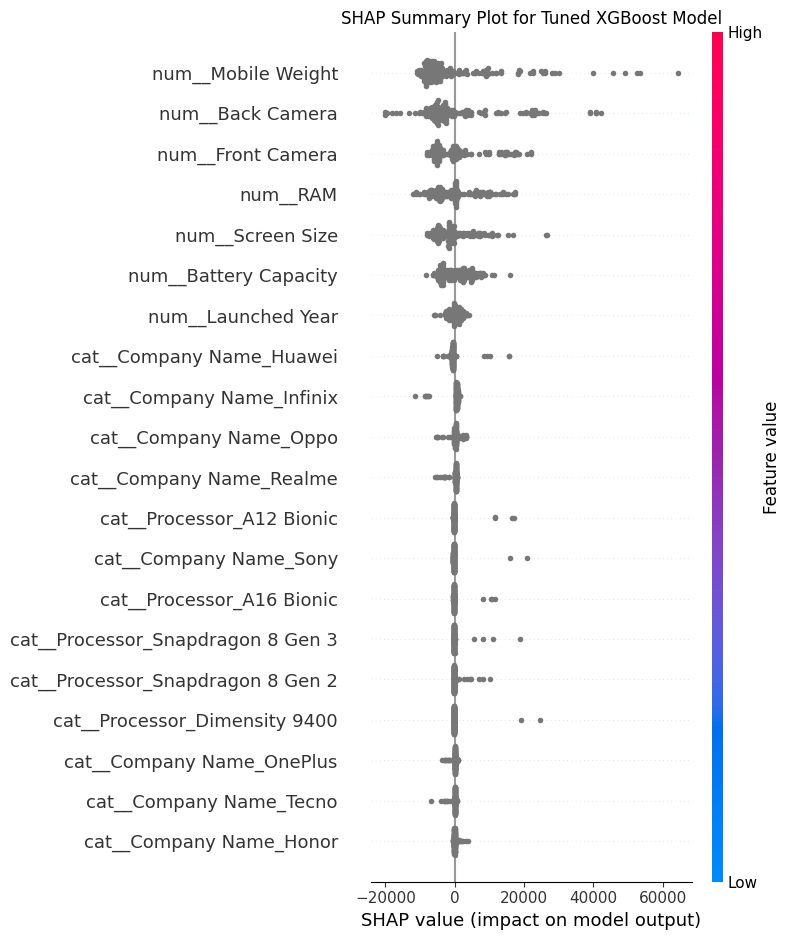

In [ ]:
# Create a SHAP Explanation object for the summary plot
# This object needs the SHAP values and the original data (with feature names)
shap_explanation = shap.Explanation(
    shap_values,
    base_values=explainer.expected_value, # Add base_values here
    data=X_test_processed_shap,
    feature_names=feature_names_out
)

# Generate the SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_explanation, show=False)
plt.title('SHAP Summary Plot for Tuned XGBoost Model')
plt.tight_layout()
plt.show()

This plot provides a clear overview of which features are most important and how their values influence the prediction (e.g., high 'Back Camera' MP tends to increase the predicted price, while low 'RAM' might decrease it). The wider the distribution of points for a feature, the more varied its impact across different predictions.

In [ ]:
import joblib
joblib.dump(best_xgb_model_tuned, 'phone_price_model.pkl')

['phone_price_model.pkl']

In this waterfall plot:

*   The **`E[f(X)]` (Expected Value)** at the bottom represents the average prediction of the model across the entire dataset. It's your baseline.
*   Each bar above `E[f(X)]` shows how a specific feature's value contributes to pushing the prediction **up** (red) or **down** (blue) from the expected value.
*   The **`f(x)` (Model Output)** at the top is the final prediction for this specific instance.

This gives you a clear, additive breakdown of how each feature's value influences the final price prediction for that particular phone. For example, a long red bar for 'num__Back Camera' means that this phone's back camera megapixels are significantly contributing to a higher predicted price compared to the average.

# SAMPLE CODES ONLY FOR TESTING THE MODEL

In [ ]:
import sklearn
import xgboost
import joblib

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Joblib:", joblib.__version__)

scikit-learn: 1.6.1
XGBoost: 3.3.0
Joblib: 1.5.3


In [ ]:
prediction = best_xgb_model_tuned.predict(X_test)

print(prediction[:5])

[15999.974 66165.27  36626.367 13747.484 31762.506]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
df["Company Name"].unique()
# df["Processor"].unique()

array(['Apple', 'Samsung', 'OnePlus', 'Vivo', 'iQOO', 'Oppo', 'Realme',
       'Xiaomi', 'Lenovo', 'Motorola', 'Huawei', 'Nokia', 'Sony',
       'Google', 'Tecno', 'Infinix', 'Honor', 'POCO', 'Poco'],
      dtype=object)

In [ ]:
import pandas as pd

# Sample phone
test_phone = pd.DataFrame([{
    "Company Name": "Samsung",
    "Mobile Weight": 195,
    "RAM": 8,
    "Front Camera": 12,
    "Back Camera": 50,
    "Processor": "Snapdragon 8 Gen 2",
    "Battery Capacity": 5000,
    "Screen Size": 6.7,
    "Launched Year": 2027
}])

# Predict
prediction = best_xgb_model_tuned.predict(test_phone)[0]

print(f"Predicted Indian Launch Price: ₹{prediction:,.2f}")

Predicted Indian Launch Price: ₹70,261.15


In [ ]:
df["Processor"].unique()

array(['A17 Bionic', 'A17 Pro', 'A16 Bionic', 'A15 Bionic', 'A14 Bionic',
       'A13 Bionic', 'A11 Bionic', 'A12 Bionic', 'A12Z Bionic',
       'Exynos 2400', 'Snapdragon 8 Gen 2', 'Exynos 2200',
       'Snapdragon 8 Gen 1', 'Exynos 1380', 'MediaTek Dimensity 1080',
       'MediaTek Helio G99', 'Exynos 850', 'Exynos 1280',
       'MediaTek Helio P35', 'Exynos 990', 'Exynos 9825',
       'Snapdragon 450', 'Exynos 7870', 'Snapdragon 425', 'Exynos 7570',
       'Snapdragon 653', 'Snapdragon 625', 'Snapdragon 617',
       'Snapdragon 888', 'Snapdragon 695', 'Unisoc T618',
       'MediaTek Helio P22T', 'Snapdragon 778G', 'Exynos 9810',
       'Spreadtrum SC8830', 'Qualcomm MSM8916', 'Snapdragon 8 Gen 3',
       'MediaTek Dimensity 9000', 'Snapdragon 782G',
       'MediaTek Dimensity 6020', 'Snapdragon 8+ Gen 1',
       'MediaTek Dimensity 1300', 'MediaTek Dimensity 1200-AI',
       'Snapdragon 480', 'Qualcomm Snapdragon 460', 'Snapdragon 865',
       'Snapdragon 870', 'MediaTek Dimensity 9